# Wprowadzenie

Celem ćwiczenia laboratoryjnego jest zapoznanie sie z najpopularniejszymi metodami wykorzystywanymi do rozwiazywania rzeczywistych problemów zespołami klasyfikatorow. W szczególności celem zadania bedzie przetestowanie modeli takich jak Random Forest, AdaBoost, Histogram-based Gradient Boosting, XGBoost, LightGBM, CatBoost

# Imports

In [49]:
from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import StandardScaler
from xgboost import XGBClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, f1_score, recall_score
from sklearn.impute import SimpleImputer

In [64]:
glass_identification = fetch_ucirepo(id=42) 

X = glass_identification.data.features 
y = glass_identification.data.targets 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

In [65]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Wybór i uruchomienie algorytmów na prostym zbiorze

## Baseline z poprzednich list

In [66]:
classes = [
    "bld_win_float",
    "bld_win_nonfloat",
    "veh_win_float",
    "containers",
    "tableware",
    "headlamps"
]

def plot_cm(cm):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
                xticklabels=classes, 
                yticklabels=classes)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

## KNN

C:\Users\mikja\AppData\Roaming\Python\Python312\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


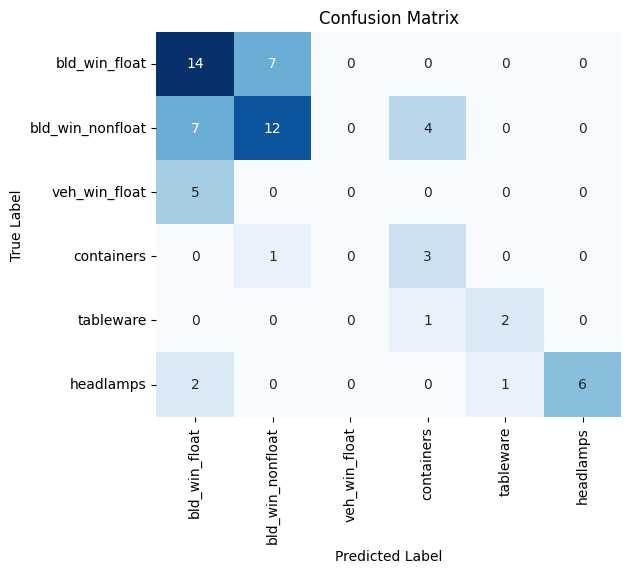

                  precision    recall  f1-score   support

   bld_win_float       0.50      0.67      0.57        21
bld_win_nonfloat       0.60      0.52      0.56        23
   veh_win_float       0.00      0.00      0.00         5
      containers       0.38      0.75      0.50         4
       tableware       0.67      0.67      0.67         3
       headlamps       1.00      0.67      0.80         9

        accuracy                           0.57        65
       macro avg       0.52      0.55      0.52        65
    weighted avg       0.57      0.57      0.55        65



In [67]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_hat = knn.predict(X_test)
plot_cm(confusion_matrix(y_test, y_hat))
print(classification_report(y_test, y_hat, target_names=classes, zero_division=0))

## Decision Tree

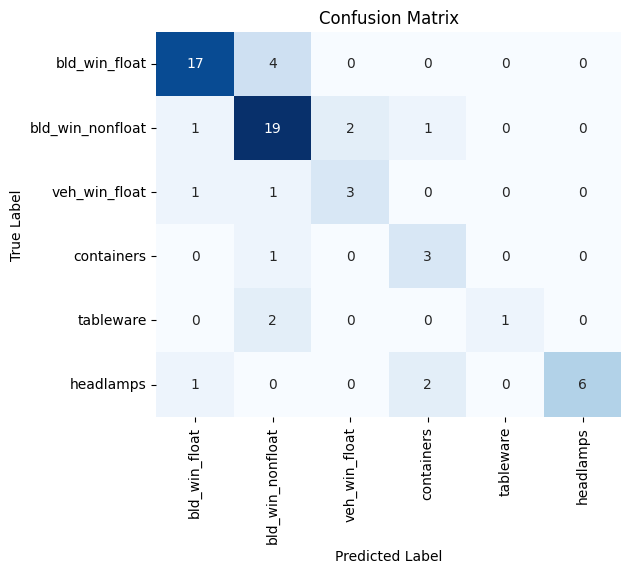

                  precision    recall  f1-score   support

   bld_win_float       0.85      0.81      0.83        21
bld_win_nonfloat       0.70      0.83      0.76        23
   veh_win_float       0.60      0.60      0.60         5
      containers       0.50      0.75      0.60         4
       tableware       1.00      0.33      0.50         3
       headlamps       1.00      0.67      0.80         9

        accuracy                           0.75        65
       macro avg       0.78      0.66      0.68        65
    weighted avg       0.79      0.75      0.75        65



In [68]:
dt_clf = DecisionTreeClassifier()
dt_clf.fit(X_train, y_train)
y_hat = dt_clf.predict(X_test)
plot_cm(confusion_matrix(y_test, y_hat))
print(classification_report(y_test, y_hat, target_names=classes, zero_division=0))

## Random Fores

C:\Users\mikja\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


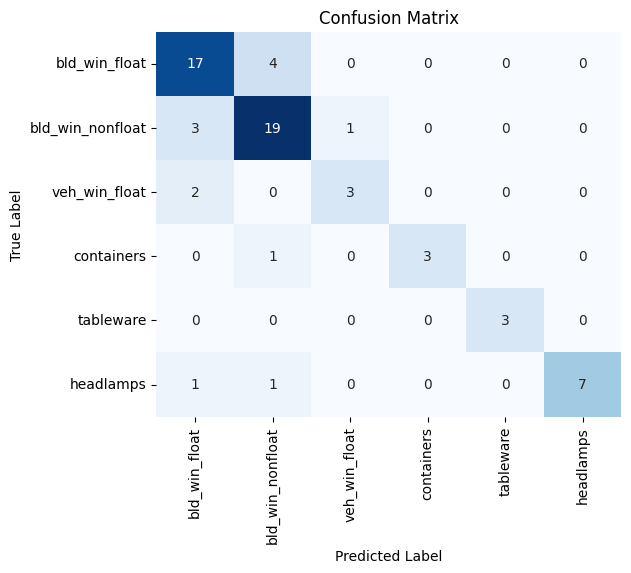

                  precision    recall  f1-score   support

   bld_win_float       0.74      0.81      0.77        21
bld_win_nonfloat       0.76      0.83      0.79        23
   veh_win_float       0.75      0.60      0.67         5
      containers       1.00      0.75      0.86         4
       tableware       1.00      1.00      1.00         3
       headlamps       1.00      0.78      0.88         9

        accuracy                           0.80        65
       macro avg       0.87      0.79      0.83        65
    weighted avg       0.81      0.80      0.80        65



In [69]:
rf_clf = RandomForestClassifier()
rf_clf.fit(X_train, y_train)
y_hat = rf_clf.predict(X_test)
plot_cm(confusion_matrix(y_test, y_hat))
print(classification_report(y_test, y_hat, target_names=classes, zero_division=0))

## AdaBoost

C:\Users\mikja\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


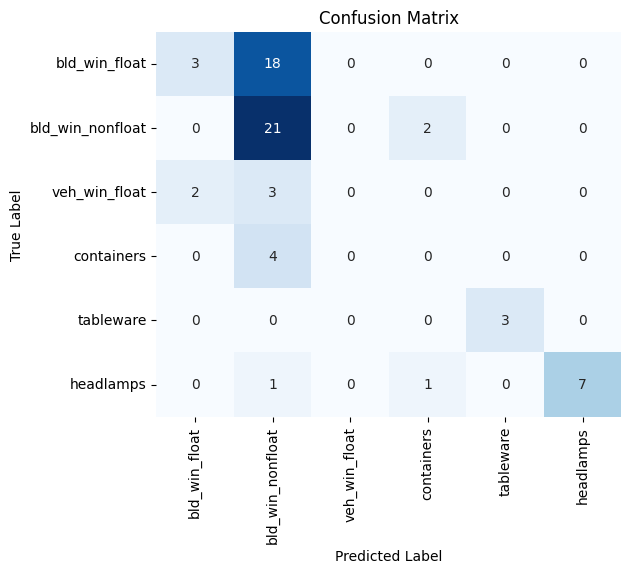

                  precision    recall  f1-score   support

   bld_win_float       0.60      0.14      0.23        21
bld_win_nonfloat       0.45      0.91      0.60        23
   veh_win_float       0.00      0.00      0.00         5
      containers       0.00      0.00      0.00         4
       tableware       1.00      1.00      1.00         3
       headlamps       1.00      0.78      0.88         9

        accuracy                           0.52        65
       macro avg       0.51      0.47      0.45        65
    weighted avg       0.54      0.52      0.45        65



In [79]:
ada_clf = AdaBoostClassifier()
ada_clf.fit(X_train, y_train)
y_hat = ada_clf.predict(X_test)
plot_cm(confusion_matrix(y_test, y_hat))
print(classification_report(y_test, y_hat, target_names=classes, zero_division=0))

## XGBoost

In [71]:
y_train = y_train - 1
y_test = y_test - 1
y_train = np.where(y_train > 2, y_train - 1, y_train)
y_test = np.where(y_test > 2, y_test - 1, y_test)

In [77]:
np.unique(y_test)

array([0, 1, 2, 3, 4, 5])

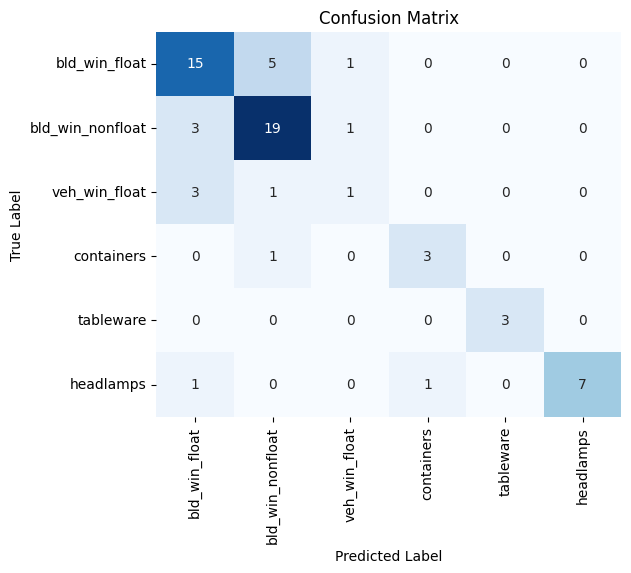

                  precision    recall  f1-score   support

   bld_win_float       0.68      0.71      0.70        21
bld_win_nonfloat       0.73      0.83      0.78        23
   veh_win_float       0.33      0.20      0.25         5
      containers       0.75      0.75      0.75         4
       tableware       1.00      1.00      1.00         3
       headlamps       1.00      0.78      0.88         9

        accuracy                           0.74        65
       macro avg       0.75      0.71      0.72        65
    weighted avg       0.74      0.74      0.73        65



In [73]:
xgb = XGBClassifier()
xgb.fit(X_train, y_train)
y_hat = xgb.predict(X_test)
plot_cm(confusion_matrix(y_test, y_hat))
print(classification_report(y_test, y_hat, target_names=classes, zero_division=0))

## Podsumowanie

| Klasyfikator  | Accuracy | Macro avg F1 | Weighted avg F1 | Uwagi |
|:---------------|:-----------|:---------------|:----------------|:-----------------------------|
| **KNN**           | 0.57      | 0.52          | 0.55             | Najniższy wynik, lecz najprostszy klasyfikator. Pominięta klasa `veh_win_float` |
| **Decision Tree** | 0.75      | 0.68          | 0.75             | Udało się nie pomijać zawsze ani jednej klasy |
| **Random Forest** | 0.80      | 0.83          | 0.80             | Najlepszy wynik; wysokie F1-score w niemal wszystkich klasach |
| **AdaBoost**      | 0.52      | 0.45          | 0.45             | Bardzo nierównomierny - kompletnie pominął często występującą klasę `bld_win_float`        i uznawał ją za klasę `bld_win_nonfloat` |
| **XGBoost**       | 0.74      | 0.72          | 0.73             | Stabilny, dobre wyniki zbliżone do Decision Tree |

